In [61]:
import os
from astropy.convolution import convolve_fft, Gaussian2DKernel

import scipy.ndimage as nd

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from matplotlib import colormaps
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm


import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.visualization import ImageNormalize, SqrtStretch
from sunpy.coordinates.ephemeris import get_body_heliographic_stonyhurst
from astropy.coordinates import solar_system_ephemeris
from astropy.modeling.functional_models import Disk2D

import sunpy.coordinates  as coord # NOQA
import sunpy.map
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.coordinates import frames

from sunkit_image.coalignment import mapsequence_coalign_by_match_template as mc_coalign
from sunkit_image.coalignment import calculate_match_template_shift as mc_shift

import numpy as np

import cmasher as cmr

from identification_utils import *

In [62]:
###Parameters to lod data

#mail access
jsoc_email = "stucki@ieec.cat"

#time range of observation
start_time ='2017-08-24T00:00:00'
end_time = '2017-08-24T00:11:00'


#data names
Ic_serie ='hmi.Ic_noLimbDark_720s'
M_serie = 'hmi.M_45s'

#directory to retrieve the files into
path = '/home/sophie-stucki/starsim/starsim/SDO_input/SDO_images'

In [63]:
###Load the data

cont_sequence, los_sequence = load_data(start_time, end_time, jsoc_email, Ic_serie, M_serie, path=path)

cont_map = cont_sequence.maps[0]
los_map = los_sequence.maps[0]

2025-05-22 12:10:08 - drms - INFO: Export request pending. [id=JSOC_20250522_001466, status=2]
2025-05-22 12:10:08 - drms - INFO: Waiting for 0 seconds...
2025-05-22 12:10:08 - sunpy - INFO: 2 URLs found for download. Full request totaling 30MB


INFO: 2 URLs found for download. Full request totaling 30MB [sunpy.net.jsoc.jsoc]


Files Downloaded: 100%|██████████| 2/2 [00:03<00:00,  1.60s/file]
2025-05-22 12:10:24 - drms - INFO: Export request pending. [id=JSOC_20250522_001469, status=2]
2025-05-22 12:10:24 - drms - INFO: Waiting for 0 seconds...
2025-05-22 12:10:25 - sunpy - INFO: 15 URLs found for download. Full request totaling 228MB


INFO: 15 URLs found for download. Full request totaling 228MB [sunpy.net.jsoc.jsoc]


Files Downloaded: 100%|██████████| 15/15 [00:23<00:00,  1.58s/file]


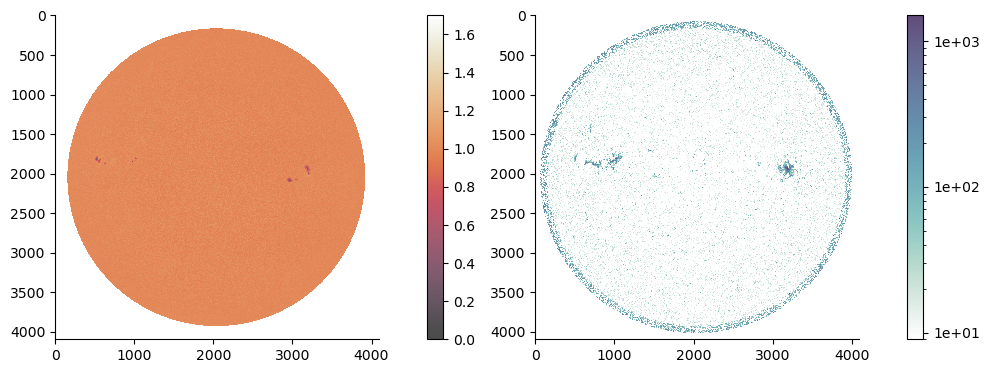

In [64]:
###Plot the first 2 maps of RAW data

# two_graphs_plot(cont_map, los_map)

RAW_size = cont_map.dimensions


two_graphs_plot(cont_map, los_map)

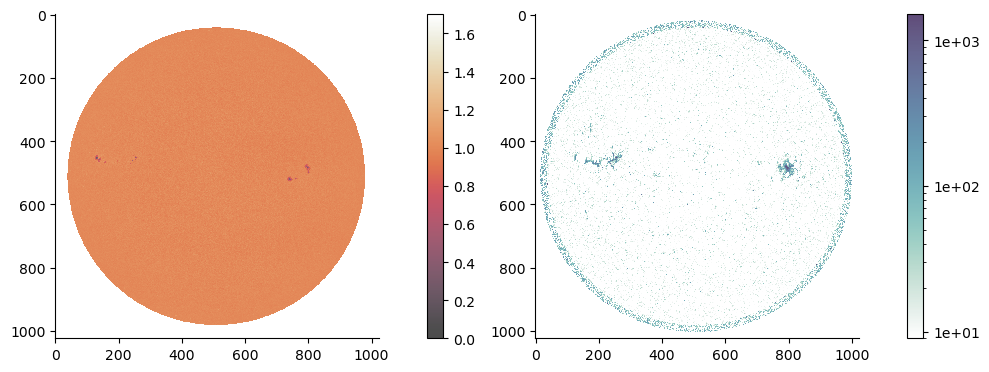

In [65]:
## Downsampling
out_shape = (1024, 1024)
#out_shape = (RAW_size[0].value, RAW_size[0].value)

cont_map = cont_map.resample(out_shape * u.pix)
los_map = los_map.resample(out_shape * u.pix)

two_graphs_plot(cont_map, los_map)

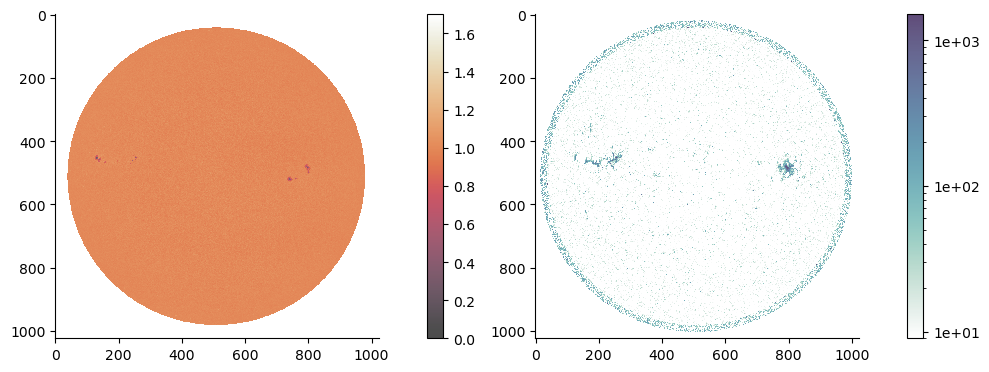

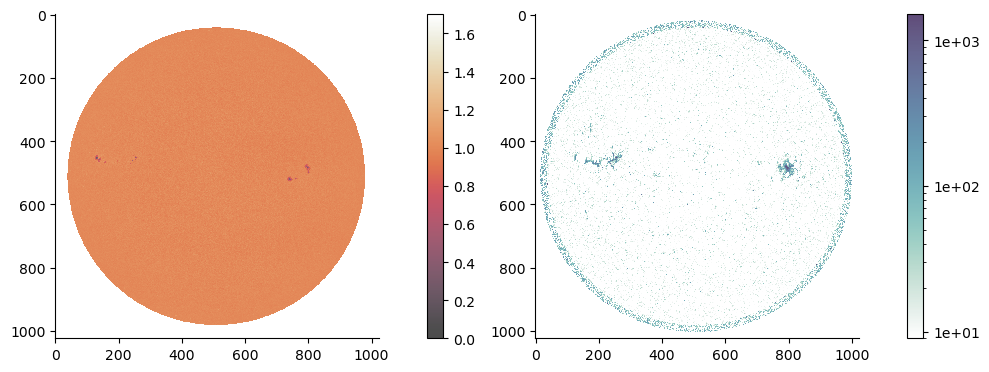

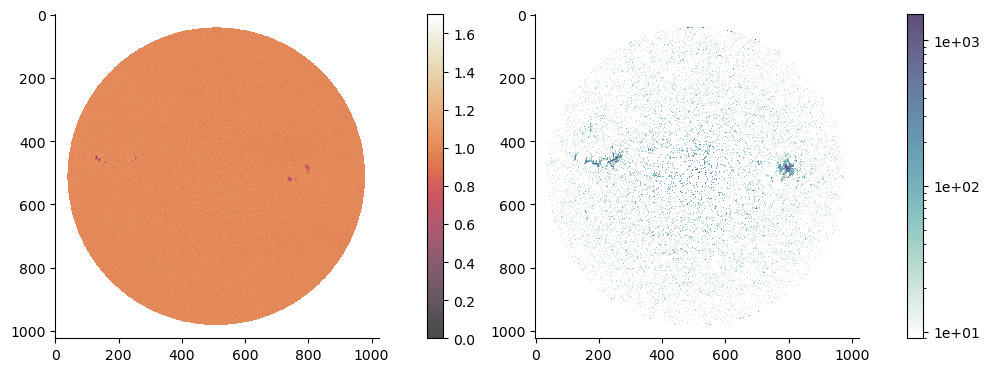

In [66]:
xg, yg = coord_grid(los_map)

two_graphs_plot(cont_map, los_map)

los_sequence_updated = sunpy.map.MapSequence(noise_threshold(los_map, threshold=8))

two_graphs_plot(cont_map, los_sequence_updated.maps[0])

los_sequence_updated = sunpy.map.MapSequence(removing_foreshortening_effect(los_sequence_updated.maps[0],xg,yg))
two_graphs_plot(cont_map, los_sequence_updated.maps[0])

3 940
[1.00837499 1.02255002]


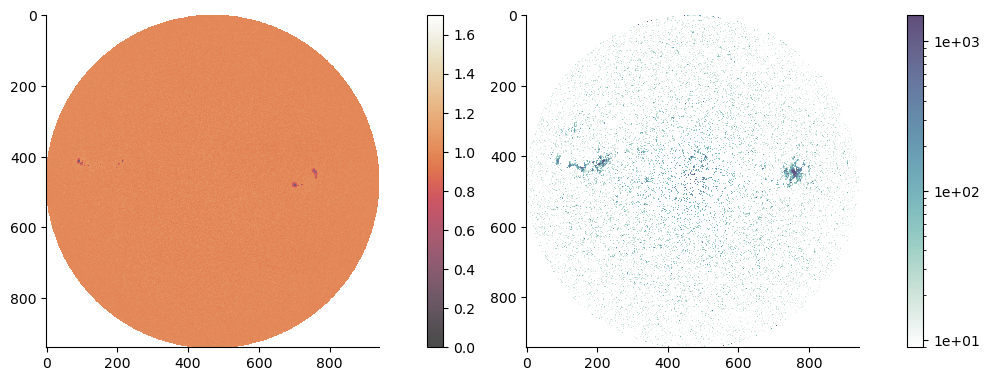

In [ ]:
print(np.argwhere(cont_map.data[512, :] >= 0 ).min(), np.argwhere(cont_map.data[512, :] >= 0 ).max())
print(cont_map.data[512, 156:158])

min_p = int(np.argwhere(cont_map.data[512, :] >= 0 ).min() - 1)
max_p = int(np.argwhere(cont_map.data[512, :] >= 0 ).max() + 1)


# Create a submap
cont_map = sunpy.map.sources.HMIMap(cont_map.data[min_p:max_p, min_p:max_p], cont_map.fits_header)
los_map = sunpy.map.sources.HMIMap(los_sequence_updated.maps[0].data[min_p:max_p, min_p:max_p], los_sequence_updated.maps[0].fits_header)



two_graphs_plot(cont_map, los_map)

xg = xg[min_p:max_p, min_p:max_p]
yg = yg[min_p:max_p, min_p:max_p]


In [75]:
np.shape(los_map.data)

(939, 939)

In [76]:
###Identification

active_area = active_area_identification(cont_map, los_map, xg, yg)
spot_area, smooth_spot_area, feature_area, smooth_feature_area = active_area_smoothing(active_area, spot_threshold=0.2, spot_kernel_size=2, feature_threshold=0.2, feature_kernel_size=2) 
# (size, threshold) for raw: spot_threshold=0.4, spot_kernel_size=6, feature_threshold=0.4, feature_kernel_size=6
#for 512 (0.2,2)
area_th = micro_hemisphere_to_arcsec2(los_sequence_updated.maps[0], 20).value
identification, plage_nbr = network_identification(feature_area, smooth_feature_area, los_map.scale[0].value, area_th, method='scipy')
nbr, locs, pxl_area = spot_nbr(spot_area, smooth_spot_area)


200


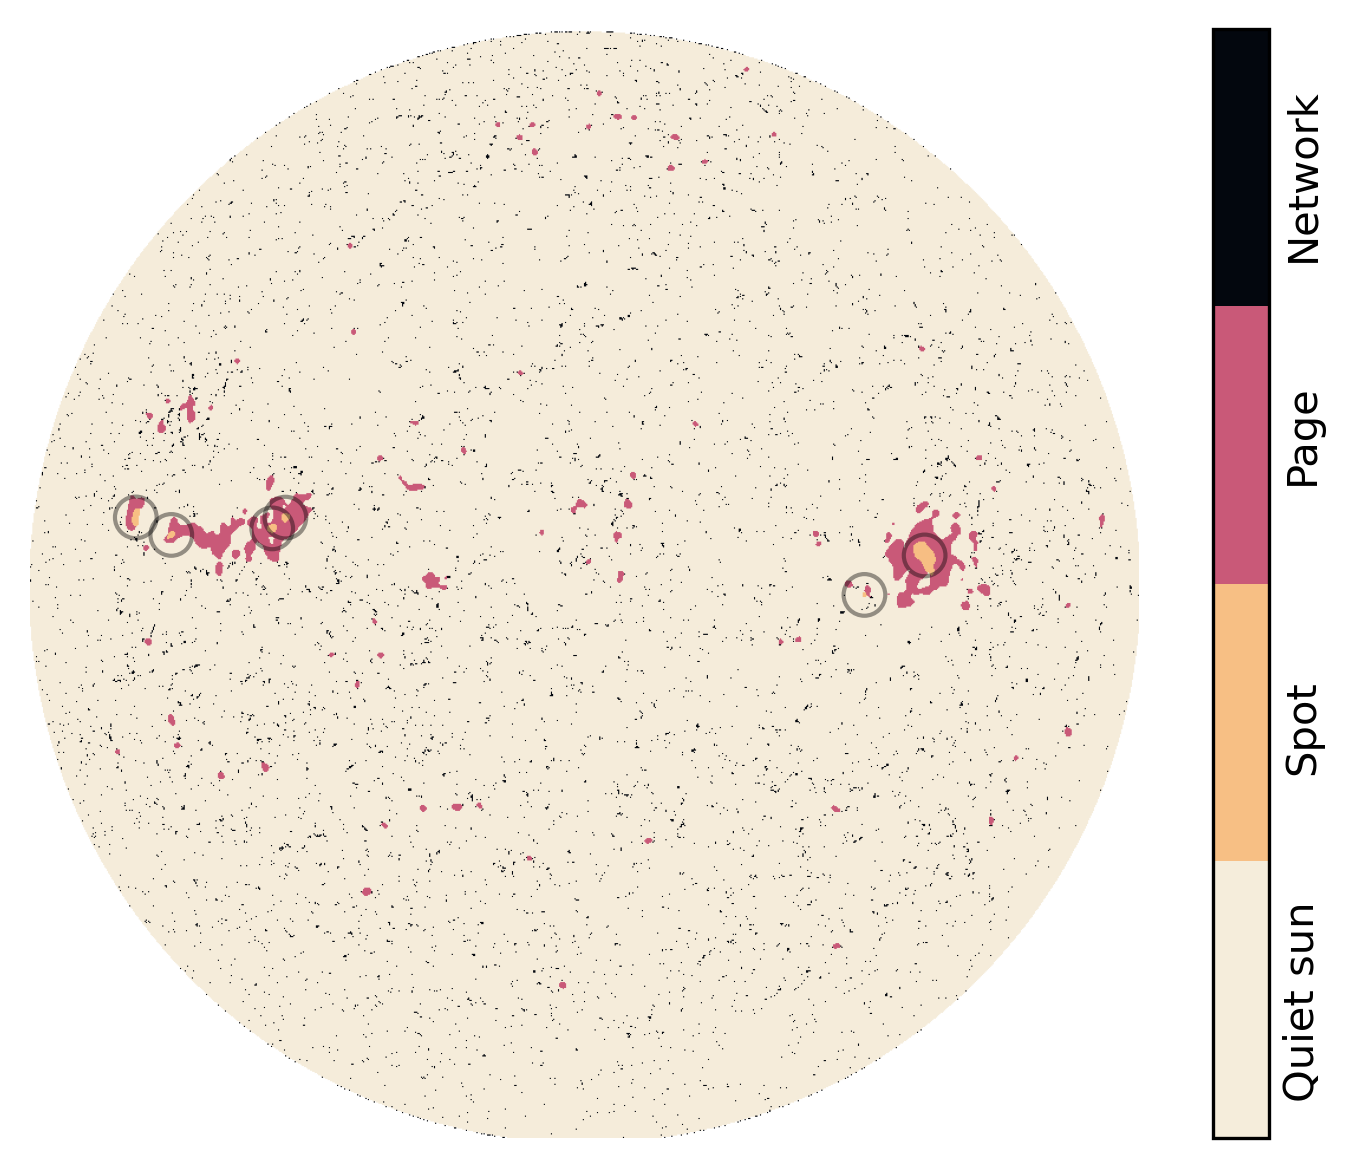

In [77]:
identifiation_plot(identification, smooth_spot_area, cont_map, locs, filename=path+'identification_map_downsampling_{}.pdf'.format(int(RAW_size[0].value/out_shape[0])))

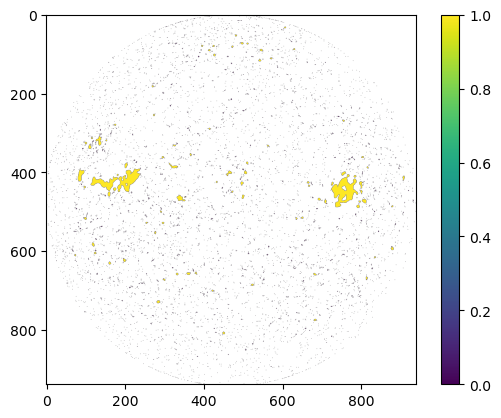

In [81]:
plt.imshow(identification)
plt.colorbar()

In [ ]:
rounded_spot_area = features_rounding(len(identification), locs, pxl_area)

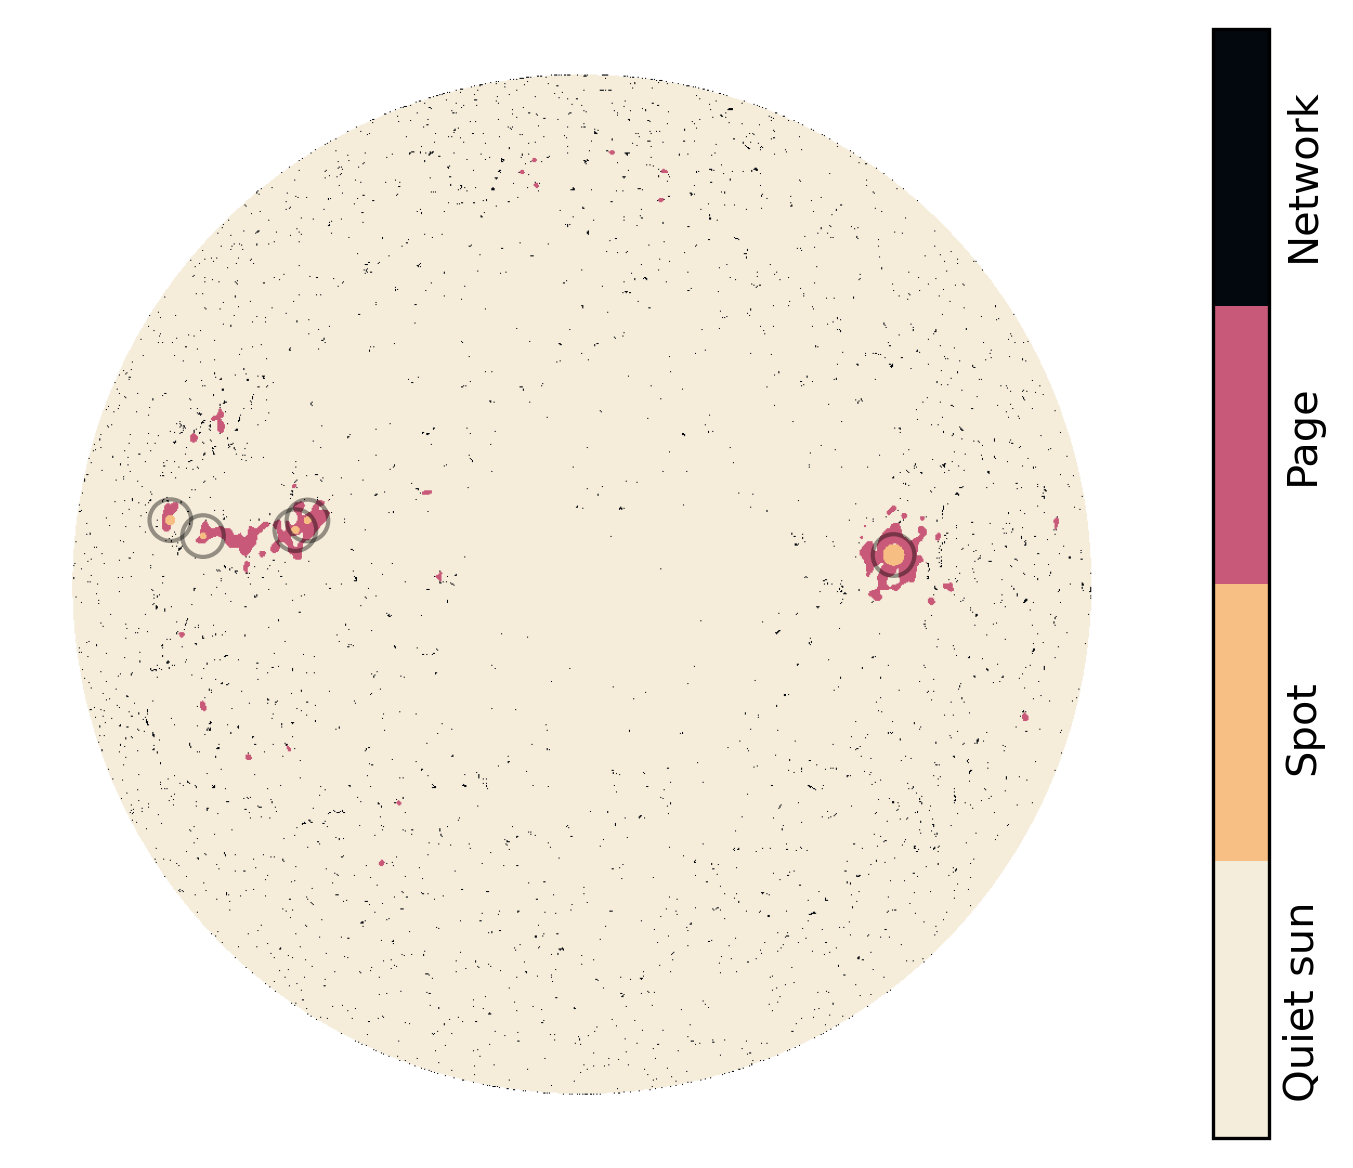

In [ ]:
identifiation_plot(identification, rounded_spot_area, cont_map, locs)

In [ ]:
from astropy.modeling.projections import Sky2Pix_ZenithalPerspective

projection = Sky2Pix_ZenithalPerspective(mu=1e3)
x,y = projection(xg.value,yg.value)

In [ ]:
def two_graphs_plot(cont_map, los_map):

    """
    Plot of the continuum and the los magnetogram sunpy map

    Params:
            - cont_map: map of the continuum data
            - los_map: map of the los magnetogram data
    
    """

    fig, axes = plt.subplots(1, 2, figsize=(10,28))  # Wider, more balanced layout

    # First subplot
    ax1 = axes[0]
    img1 = ax1.imshow(cont_map.data, cmap=cmr.sunburst, norm=ImageNormalize(vmin=0., vmax=1.7), alpha=0.7, interpolation='nearest')

    # Create smaller colorbar for first plot
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.48)  # Adjust size (5% width) and padding
    cbar1 = fig.colorbar(img1, cax=cax1, orientation='vertical')

    # Second subplot
    ax2 = axes[1]
    norm = colors.LogNorm(vmin=9e0, vmax=1.5e3)  # Define log normalization for second plot
    img2 = ax2.imshow(los_map.data,  cmap=cmr.ocean_r, norm=norm, alpha=0.7, interpolation='nearest')
    

    # Create smaller colorbar for second plot
    divider2 = make_axes_locatable(ax2)
    cax2 = divider2.append_axes("right", size="5%", pad=0.48)  # Adjust size (5% width) and padding
    cbar2 = fig.colorbar(img2, cax=cax2, orientation='vertical', norm=norm, format="{x:.0e}")

    """# Selecting the axis-X making the bottom and top axes False for both subplots
    ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax2.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # Selecting the axis-Y making the right and left axes False for both subplots
    ax1.tick_params(axis='y', which='both', right=False, left=False, labelleft=False)
    ax2.tick_params(axis='y', which='both', right=False, left=False, labelleft=False)"""

    # Iterating over all the axes in the figure and making the Spines Visibility as False for both subplots
    for ax in [ax1, ax2]:
        for pos in ['right', 'top']:
                ax.spines[pos].set_visible(False)



    plt.tight_layout()
    plt.show()


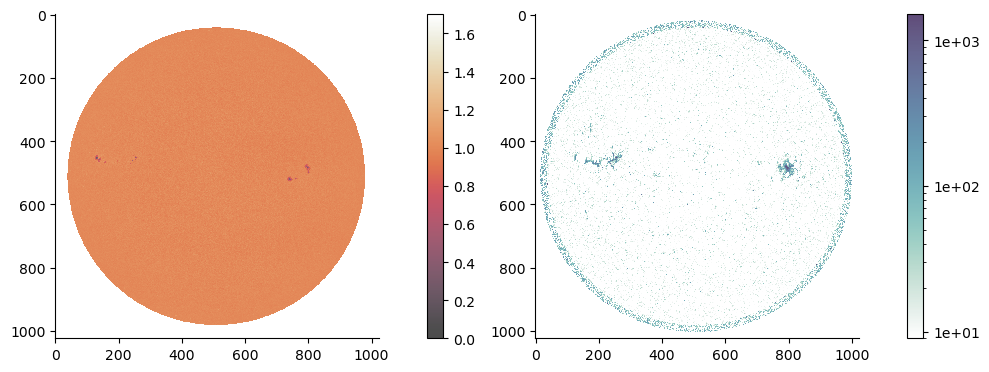

In [ ]:
two_graphs_plot(cont_map, los_map)

In [ ]:
los_map.dsun

<Distance 1.51241684e+11 m>